In [11]:
from __future__ import annotations

import ssl
from pathlib import Path
from urllib.request import urlopen
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter


In [12]:
# ============================================================
# CONFIGURACIÓN  DE DATOS PARA ORINOQUIA COLOMBIANA
# ============================================================
MONTHS = np.arange(1, 13)
MONTH_LABELS = ["Ene", "Feb", "Mar", "Abr", "May", "Jun", "Jul", "Ago", "Sep", "Oct", "Nov", "Dic"]

VAR_META = {
    "t2m": {"label": "Temperatura 2 m", "unit_out": "°C", "convert": lambda x: x - 273.15},
    "sp": {"label": "Presión superficial", "unit_out": "hPa", "convert": lambda x: x / 100.0},
    "u10": {"label": "Viento zonal 10 m (u)", "unit_out": "m s$^{-1}$", "convert": lambda x: x},
    "v10": {"label": "Viento meridional 10 m (v)", "unit_out": "m s$^{-1}$", "convert": lambda x: x},
    "ws10": {"label": "Rapidez del viento 10 m", "unit_out": "m s$^{-1}$", "convert": lambda x: x},
}

# Departamentos de la Orinoquia colombiana (coordenadas aproximadas)
DEPARTAMENTOS = {
    "Arauca":        (-71.0, 6.8),
    "Casanare":      (-71.5, 5.5),
    "Meta":          (-72.5, 4.5),
    "Vichada":       (-69.5, 5.5),
    "Boyacá":        (-73.0, 6.0),
    "Cundinamarca":  (-74.0, 5.0),
    "Norte de Santander": (-72.5, 7.5)
}

# ============================================================
# RUTAS DE ENTRADA Y SALIDA 
# ============================================================
# Ruta al archivo NetCDF descargado 
IN_NC = Path("p:/clima/data/raw/era5_surface_monthly_1991_2020.nc")

# Carpetas de salida
PROJECT_ROOT = IN_NC.parent.parent.parent  # sube hasta p:/clima
RESULTS_DIR = PROJECT_ROOT / "results"
DOCS_DIR = PROJECT_ROOT / "docs"

OUT_CSV = RESULTS_DIR / "tables" / "03_climatologia_mensual_orinoquia.csv"
OUT_SERIES_PNG = RESULTS_DIR / "plots" / "03_climatologia_mensual_superficie_orinoquia.png"
OUT_MAP_SP_UV_PNG = RESULTS_DIR / "plots" / "03_mapa_presion_isobaras_viento_orinoquia.png"
OUT_MAP_T_PNG = RESULTS_DIR / "plots" / "03_mapa_temperatura_orinoquia.png"
OUT_MD = DOCS_DIR / "report" / "03_item3_climatologias_orinoquia.md"

# Crear directorios si no existen
OUT_CSV.parent.mkdir(parents=True, exist_ok=True)
OUT_SERIES_PNG.parent.mkdir(parents=True, exist_ok=True)
OUT_MAP_SP_UV_PNG.parent.mkdir(parents=True, exist_ok=True)
OUT_MAP_T_PNG.parent.mkdir(parents=True, exist_ok=True)
OUT_MD.parent.mkdir(parents=True, exist_ok=True)

# ============================================================
# SE DEFINES ALGUNAS FUNCIONES 
# ============================================================
def _download_basemap(lon_min: float, lat_min: float, lon_max: float, lat_max: float, out_png: Path) -> Path | None:
    """Descarga fondo de mapa (ArcGIS World Topo) para el bbox en EPSG:4326."""
    url = (
        "https://server.arcgisonline.com/ArcGIS/rest/services/World_Topo_Map/MapServer/export"
        f"?bbox={lon_min},{lat_min},{lon_max},{lat_max}"
        "&bboxSR=4326&imageSR=4326&size=1200,900&format=png&f=image"
    )
    try:
        out_png.parent.mkdir(parents=True, exist_ok=True)
        ctx = ssl._create_unverified_context()
        with urlopen(url, context=ctx, timeout=30) as resp:
            data = resp.read()
        out_png.write_bytes(data)
        return out_png if out_png.exists() and out_png.stat().st_size > 0 else None
    except Exception:
        return None


def _annotate_departamentos(ax, lon_min: float, lat_min: float, lon_max: float, lat_max: float) -> None:
    """Añade nombres de departamentos (opcional)."""
    for nombre, (lon, lat) in DEPARTAMENTOS.items():
        if lon_min <= lon <= lon_max and lat_min <= lat <= lat_max:
            ax.scatter(lon, lat, s=40, c="yellow", edgecolors="black", linewidths=0.7, zorder=6)
            ax.text(
                lon + 0.05,
                lat + 0.02,
                nombre,
                fontsize=9,
                fontweight="bold",
                color="black",
                zorder=7,
                bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="black", alpha=0.85),
            )


def _open_dataset(nc_path: Path) -> xr.Dataset:
    return xr.open_dataset(nc_path)


def _time_dim(ds: xr.Dataset) -> str:
    return "time" if "time" in ds.dims else "valid_time"


def compute_climatology_monthly_regional(ds: xr.Dataset) -> pd.DataFrame:
    """Calcula climatología mensual regional (promedio ponderado por cos(lat))."""
    rows = []
    tdim = _time_dim(ds)

    lat_weights = np.cos(np.deg2rad(ds["latitude"]))
    lat_weights = lat_weights / lat_weights.mean()

    ws10 = np.sqrt(ds["u10"] ** 2 + ds["v10"] ** 2)

    for var, meta in VAR_META.items():
        da = ws10 if var == "ws10" else ds[var]

        ts_region = da.weighted(lat_weights).mean(dim=("latitude", "longitude"), skipna=True)
        ts_region = meta["convert"](ts_region)

        clim_mean = ts_region.groupby(f"{tdim}.month").mean(tdim, skipna=True)
        clim_std = ts_region.groupby(f"{tdim}.month").std(tdim, skipna=True)

        for m in MONTHS:
            rows.append(
                {
                    "variable": var,
                    "descripcion": meta["label"],
                    "unidad": meta["unit_out"],
                    "month": int(m),
                    "month_name": MONTH_LABELS[m - 1],
                    "clim_mean": float(clim_mean.sel(month=m).item()),
                    "clim_std": float(clim_std.sel(month=m).item()),
                }
            )

    return pd.DataFrame(rows)


def compute_annual_mean_fields(ds: xr.Dataset) -> dict[str, xr.DataArray]:
    """Campo climatológico medio multianual (promedio de todos los meses)."""
    tdim = _time_dim(ds)

    t2m_c = VAR_META["t2m"]["convert"](ds["t2m"])
    sp_hpa = VAR_META["sp"]["convert"](ds["sp"])
    u10 = ds["u10"]
    v10 = ds["v10"]

    return {
        "t2m": t2m_c.mean(tdim, skipna=True),
        "sp": sp_hpa.mean(tdim, skipna=True),
        "u10": u10.mean(tdim, skipna=True),
        "v10": v10.mean(tdim, skipna=True),
    }


def plot_climatology_monthly(df: pd.DataFrame, out_png: Path) -> None:
    """Gráfico de series mensuales (media ± desviación) para cada variable."""
    vars_to_plot = list(VAR_META.keys())
    n = len(vars_to_plot)
    ncols = 2
    nrows = int(np.ceil(n / ncols))

    fig, axes = plt.subplots(nrows, ncols, figsize=(12, 3.6 * nrows), sharex=True)
    axes = np.array(axes).reshape(-1)

    for ax, var in zip(axes, vars_to_plot):
        d = df[df["variable"] == var].sort_values("month")
        x = d["month"].to_numpy()
        y = d["clim_mean"].to_numpy()
        s = d["clim_std"].to_numpy()

        ax.plot(x, y, lw=2)
        ax.fill_between(x, y - s, y + s, alpha=0.2)
        ax.set_title(f"{VAR_META[var]['label']} [{VAR_META[var]['unit_out']}]")
        ax.set_xticks(MONTHS)
        ax.set_xticklabels(MONTH_LABELS)
        ax.grid(alpha=0.3)

    for ax in axes[n:]:
        ax.axis("off")

    fig.suptitle("MP2 — Ítem 3: climatología mensual regional (1991–2020) – Orinoquia colombiana", fontsize=12)
    fig.tight_layout()
    fig.savefig(out_png, dpi=220)
    plt.close(fig)


def plot_map_pressure_wind(fields: dict[str, xr.DataArray], out_png: Path, basemap_path: Path | None = None) -> None:
    """Mapa de presión + isobaras + vectores de viento (observado)."""
    lon = fields["sp"]["longitude"].values
    lat = fields["sp"]["latitude"].values
    sp = fields["sp"].values
    u = fields["u10"].values
    v = fields["v10"].values

    lon_min, lon_max = float(np.min(lon)), float(np.max(lon))
    lat_min, lat_max = float(np.min(lat)), float(np.max(lat))

    fig, ax = plt.subplots(figsize=(8, 6))

    if basemap_path and basemap_path.exists():
        img = plt.imread(basemap_path)
        ax.imshow(img, extent=[lon_min, lon_max, lat_min, lat_max], origin="upper", alpha=0.85, zorder=0)

    cf = ax.contourf(lon, lat, sp, levels=12, cmap="coolwarm", alpha=0.52, zorder=2)
    cbar = fig.colorbar(cf, ax=ax, shrink=0.95)
    cbar.set_label("Presión superficial climatológica [hPa]")

    cs = ax.contour(lon, lat, sp, levels=8, colors="white", linewidths=1.2, zorder=4)
    ax.clabel(cs, inline=True, fontsize=8, fmt="%.1f")

    step = 1 if len(lat) <= 10 else 2
    q = ax.quiver(
        lon[::step],
        lat[::step],
        u[::step, ::step],
        v[::step, ::step],
        color="black",
        scale=8,
        width=0.003,
        zorder=5,
    )
    ax.quiverkey(q, 0.90, -0.08, 1.0, "1 m s$^{-1}$", labelpos="E")

    _annotate_departamentos(ax, lon_min, lat_min, lon_max, lat_max)

    ax.set_title("MP2 Ítem 3 — Mapa climatológico: presión + isobaras + viento 10 m\nOrinoquia colombiana")
    ax.set_xlabel("Longitud [°]")
    ax.set_ylabel("Latitud [°]")
    ax.set_xlim(lon_min, lon_max)
    ax.set_ylim(lat_min, lat_max)
    ax.grid(alpha=0.25)

    fig.tight_layout()
    fig.savefig(out_png, dpi=220, bbox_inches="tight")
    plt.close(fig)


def plot_map_temperature(fields: dict[str, xr.DataArray], out_png: Path, basemap_path: Path | None = None) -> None:
    """Mapa de temperatura con isotermas."""
    lon = fields["t2m"]["longitude"].values
    lat = fields["t2m"]["latitude"].values
    t2m = fields["t2m"].values

    lon_min, lon_max = float(np.min(lon)), float(np.max(lon))
    lat_min, lat_max = float(np.min(lat)), float(np.max(lat))

    fig, ax = plt.subplots(figsize=(8, 6))

    if basemap_path and basemap_path.exists():
        img = plt.imread(basemap_path)
        ax.imshow(img, extent=[lon_min, lon_max, lat_min, lat_max], origin="upper", alpha=0.85, zorder=0)

    cf = ax.contourf(lon, lat, t2m, levels=12, cmap="plasma", alpha=0.52, zorder=2)
    cbar = fig.colorbar(cf, ax=ax, shrink=0.95)
    cbar.set_label("Temperatura 2 m climatológica [°C]")

    cs = ax.contour(lon, lat, t2m, levels=8, colors="k", linewidths=0.8, alpha=0.7, zorder=4)
    ax.clabel(cs, inline=True, fontsize=8, fmt="%.2f")

    _annotate_departamentos(ax, lon_min, lat_min, lon_max, lat_max)

    ax.set_title("MP2 Ítem 3 — Mapa climatológico: temperatura 2 m\nOrinoquia colombiana")
    ax.set_xlabel("Longitud [°]")
    ax.set_ylabel("Latitud [°]")
    ax.set_xlim(lon_min, lon_max)
    ax.set_ylim(lat_min, lat_max)
    ax.grid(alpha=0.25)

    fig.tight_layout()
    fig.savefig(out_png, dpi=220, bbox_inches="tight")
    plt.close(fig)


def write_report(df: pd.DataFrame, out_md: Path) -> None:
    """Genera un breve reporte en Markdown con los resultados."""
    lines = []
    lines.append("# MP2 — Ítem 3 (climatologías regionales – Orinoquia colombiana)\n")
    lines.append("## Estado")
    lines.append("Completado (series climatológicas regionales + mapas climatológicos solicitados).\n")

    lines.append("## Metodología")
    lines.append("- Fuente: `data/raw/era5_surface_monthly_1991_2020.nc`.")
    lines.append("- Variables base: t2m, sp, u10, v10; derivada: ws10 = √(u10²+v10²).")
    lines.append("- Periodo: 1991–2020 (360 meses).")
    lines.append("- Dominio: Orinoquia colombiana (lon: -74° a -67°, lat: 2° a 8°).")
    lines.append("- Media regional mensual: ponderación areal cos(lat).")
    lines.append("- Mapas: climatología media multianual de cada campo (promedio temporal 1991–2020).\n")

    lines.append("## Salidas")
    lines.append(f"- Tabla: `{OUT_CSV.relative_to(PROJECT_ROOT)}`")
    lines.append(f"- Figura (series): `{OUT_SERIES_PNG.relative_to(PROJECT_ROOT)}`")
    lines.append(f"- Figura (mapa presión+isobaras+viento): `{OUT_MAP_SP_UV_PNG.relative_to(PROJECT_ROOT)}`")
    lines.append(f"- Figura (mapa temperatura): `{OUT_MAP_T_PNG.relative_to(PROJECT_ROOT)}`\n")

    lines.append("## Resumen numérico (promedio anual de la climatología mensual)")
    for var, meta in VAR_META.items():
        d = df[df["variable"] == var]
        annual_mean = d["clim_mean"].mean()
        annual_std_mean = d["clim_std"].mean()
        lines.append(
            f"- {meta['label']}: media anual climatológica = {annual_mean:.3f} {meta['unit_out']}; "
            f"variabilidad interanual media mensual = {annual_std_mean:.3f} {meta['unit_out']}"
        )

    out_md.write_text("\n".join(lines), encoding="utf-8")


# ============================================================
# EJECUCIÓN PRINCIPAL (para notebook)
# ============================================================

ds = _open_dataset(IN_NC)
df = compute_climatology_monthly_regional(ds)
df.to_csv(OUT_CSV, index=False)

fields = compute_annual_mean_fields(ds)

# Obtener límites reales de los datos (para el fondo de mapa)
lon = fields["sp"]["longitude"].values
lat = fields["sp"]["latitude"].values
lon_min, lon_max = float(np.min(lon)), float(np.max(lon))
lat_min, lat_max = float(np.min(lat)), float(np.max(lat))

basemap_path = RESULTS_DIR / "plots" / "03_basemap_arcgis_orinoquia.png"
basemap_path = _download_basemap(lon_min, lat_min, lon_max, lat_max, basemap_path)

plot_climatology_monthly(df, OUT_SERIES_PNG)
plot_map_pressure_wind(fields, OUT_MAP_SP_UV_PNG, basemap_path=basemap_path)
plot_map_temperature(fields, OUT_MAP_T_PNG, basemap_path=basemap_path)



In [13]:
#!/usr/bin/env python3
"""Genera mapa base cartográfico para la Orinoquia colombiana (MP2) – versión notebook."""

# ============================================================
# LÍMITES DE LA REGIÓN (Orinoquia colombiana)
# ============================================================
LON_MIN, LON_MAX = -74.0, -67.0
LAT_MIN, LAT_MAX = 2.0, 8.0

# ============================================================
# CIUDADES Y POBLACIONES PRINCIPALES DENTRO DEL ÁREA
# ============================================================
CITIES = {
    "Yopal":        (5.3385, -72.3935),      # Casanare
    "Villavicencio": (4.1384, -73.6321),      # Meta
    "Arauca":       (7.0905, -70.7616),       # Arauca
    "Puerto Carreño": (6.1877, -67.4859),     # Vichada
    "San José del Guaviare": (2.5727, -72.6425), # Guaviare (sur)
    "Tame":         (6.4609, -71.7464),       # Arauca (norte)
    "Acacías":      (3.9913, -73.7575),       # Meta
    "Paz de Ariporo": (5.8852, -71.8950),     # Casanare
    "Puerto López":  (4.0892, -72.9623),      # Meta
    "La Macarena":   (2.1833, -73.7833),      # Meta (sur)
}

# ============================================================
# RUTAS (definidas manualmente para notebook)
# ============================================================
# Usa tu ruta base del proyecto. Por ejemplo:
BASE_DIR = Path("p:/clima")        # <--- AJUSTA ESTA RUTA SI ES NECESARIO
PLOTS_DIR = BASE_DIR / "results" / "plots"
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

BASEMAP_FILE = PLOTS_DIR / "03_basemap_arcgis_orinoquia.png"
OUT_MAP_FILE = PLOTS_DIR / "03_mapa_base_orinoquia.png"

# ============================================================
# FUNCIONES
# ============================================================
def download_basemap(out_path: Path) -> None:
    """Descarga fondo de mapa ArcGIS World Topo para el bbox."""
    url = (
        "https://server.arcgisonline.com/ArcGIS/rest/services/World_Topo_Map/MapServer/export"
        f"?bbox={LON_MIN},{LAT_MIN},{LON_MAX},{LAT_MAX}"
        "&bboxSR=4326&imageSR=4326&size=2000,1500&format=png&f=image"
    )
    ctx = ssl._create_unverified_context()
    with urlopen(url, context=ctx, timeout=30) as r:
        out_path.write_bytes(r.read())

# ============================================================
# EJECUCIÓN PRINCIPAL
# ============================================================

download_basemap(BASEMAP_FILE)

img = plt.imread(BASEMAP_FILE)
fig, ax = plt.subplots(figsize=(10, 12))
ax.imshow(img, extent=[LON_MIN, LON_MAX, LAT_MIN, LAT_MAX], origin="upper")

for name, (lat, lon) in CITIES.items():
    if LAT_MIN <= lat <= LAT_MAX and LON_MIN <= lon <= LON_MAX:
        ax.scatter(lon, lat, s=75, c="yellow", edgecolors="black", linewidths=1.0, zorder=3)
        ax.text(
            lon + 0.05,
            lat + 0.03,
            name,
            fontsize=9,
            fontweight="bold",
            color="black",
            bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="black", alpha=0.88),
            zorder=4,
        )

ax.set_title("Mapa base cartográfico – Orinoquia colombiana (MP2)")
ax.set_xlabel("Longitud [°]")
ax.set_ylabel("Latitud [°]")
ax.set_xlim(LON_MIN, LON_MAX)
ax.set_ylim(LAT_MIN, LAT_MAX)
ax.grid(alpha=0.25)

fig.tight_layout()
fig.savefig(OUT_MAP_FILE, dpi=240)
plt.close(fig)

print(f"[OK] Mapa base generado: {OUT_MAP_FILE}")

[OK] Mapa base generado: p:\clima\results\plots\03_mapa_base_orinoquia.png


Cargando datos...
Datos cargados.
Se tiene ya el fondo de mapa.


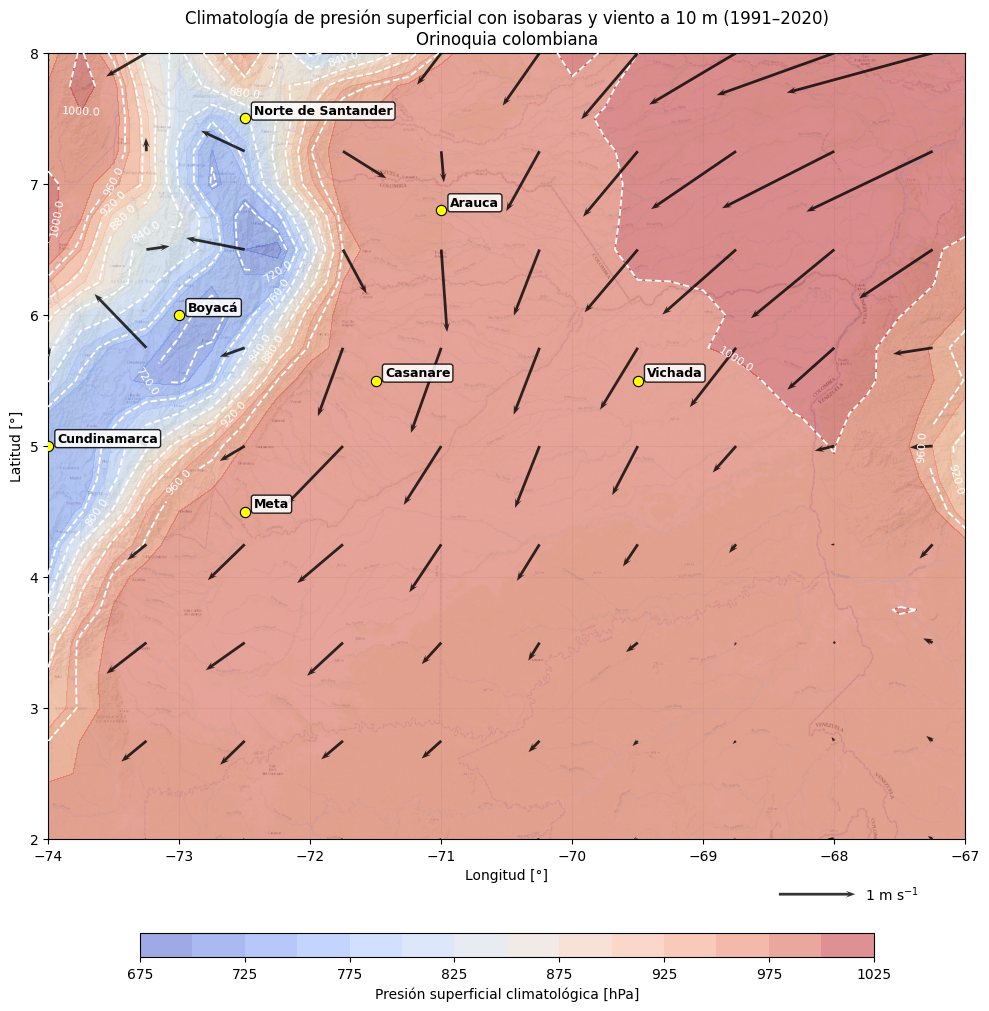

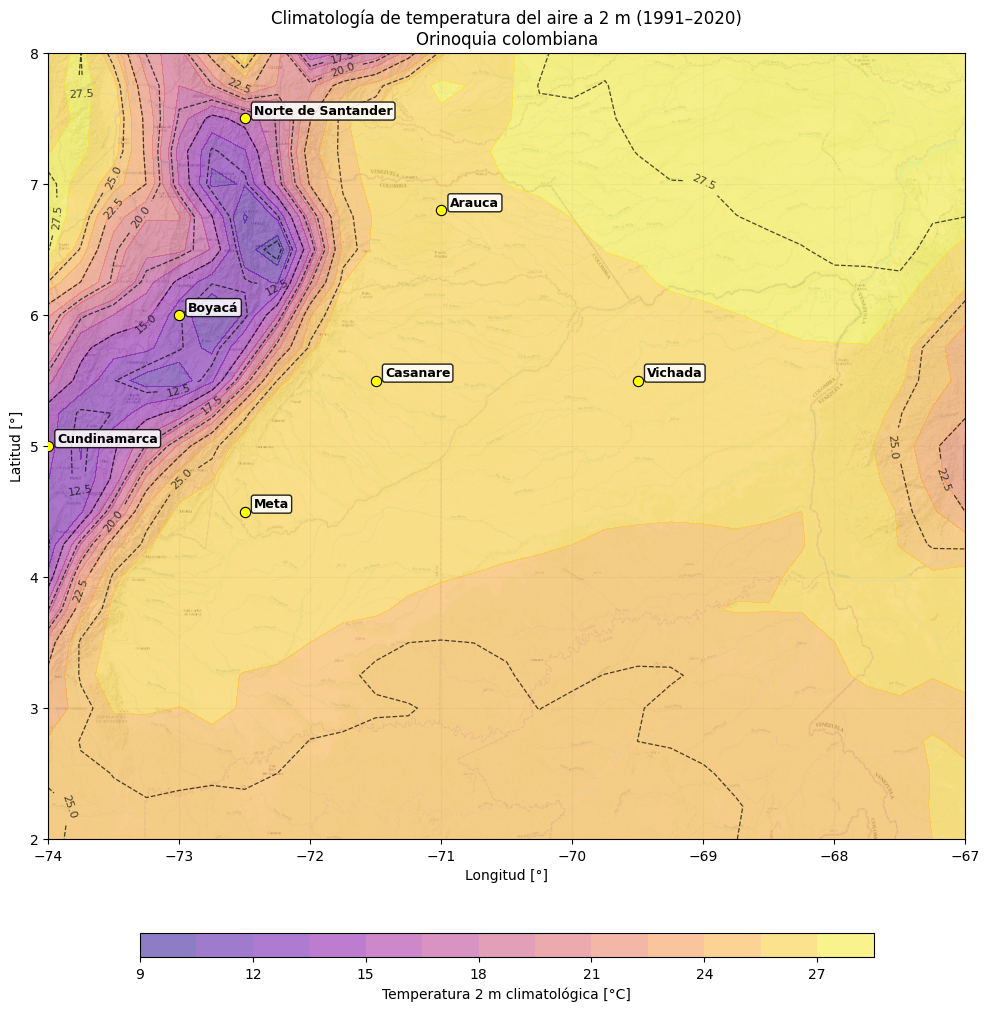

In [14]:
# ============================================================
# MAPAS CLIMATOLÓGICOS FINALES – ORINOQUIA COLOMBIANA
# (con vectores reducidos, colorbar abajo y visualización en notebook)
# ============================================================

# Configuración para mostrar gráficos en el notebook
%matplotlib inline

# ============================================================
# 1. CONFIGURACIÓN GEOGRÁFICA Y DE ARCHIVOS
# ============================================================
LON_MIN, LON_MAX = -74.0, -67.0
LAT_MIN, LAT_MAX = 2.0, 8.0

# Ruta al archivo NetCDF (ajústala si es necesario)
DATA_PATH = Path("p:/clima/data/raw/era5_surface_monthly_1991_2020.nc")

# Directorio de salida (para guardar las imágenes, opcional)
OUT_DIR = Path("p:/clima/results/plots")
OUT_DIR.mkdir(parents=True, exist_ok=True)

BASEMAP_PATH = OUT_DIR / "03_basemap_orinoquia.png"
# Si prefieres no guardar las imágenes, comenta las líneas con savefig

# ============================================================
# 2. FUNCIONES AUXILIARES
# ============================================================
def download_basemap(out_path: Path) -> None:
    """Descarga fondo de mapa ArcGIS World Topo para la región."""
    url = (
        "https://server.arcgisonline.com/ArcGIS/rest/services/World_Topo_Map/MapServer/export"
        f"?bbox={LON_MIN},{LAT_MIN},{LON_MAX},{LAT_MAX}"
        "&bboxSR=4326&imageSR=4326&size=2000,1500&format=png&f=image"
    )
    ctx = ssl._create_unverified_context()
    with urlopen(url, context=ctx, timeout=30) as r:
        out_path.write_bytes(r.read())
    print(f"Fondo de mapa descargado: {out_path}")

def annotate_departamentos(ax):
    """Añade nombres de departamentos de la Orinoquia."""
    departamentos = {
        "Arauca":          (-71.0, 6.8),
        "Casanare":        (-71.5, 5.5),
        "Meta":            (-72.5, 4.5),
        "Vichada":         (-69.5, 5.5),
        "Boyacá":          (-73.0, 6.0),
        "Cundinamarca":    (-74.0, 5.0),
        "Norte de Santander": (-72.5, 7.5)
    }
    for nombre, (lon, lat) in departamentos.items():
        if LON_MIN <= lon <= LON_MAX and LAT_MIN <= lat <= LAT_MAX:
            ax.scatter(lon, lat, s=55, c="yellow", edgecolors="black", linewidths=0.8, zorder=6)
            ax.text(
                lon + 0.07,
                lat + 0.03,
                nombre,
                fontsize=9,
                fontweight="bold",
                color="black",
                bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="black", alpha=0.85),
                zorder=7,
            )

# ============================================================
# 3. CARGA Y PROCESAMIENTO DE DATOS
# ============================================================
print("Cargando datos...")
ds = xr.open_dataset(DATA_PATH)

tdim = "time" if "time" in ds.dims else "valid_time"


sp = (ds["sp"] / 100.0).mean(tdim, skipna=True)       # hPa
t2m = (ds["t2m"] - 273.15).mean(tdim, skipna=True)   # °C
u10 = ds["u10"].mean(tdim, skipna=True)
v10 = ds["v10"].mean(tdim, skipna=True)

lon = sp["longitude"].values
lat = sp["latitude"].values

print("Datos cargados.")

# ============================================================
# 4. DESCARGA DEL FONDO DE MAPA (si no existe)
# ============================================================
if not BASEMAP_PATH.exists():
    download_basemap(BASEMAP_PATH)
else:
    print("Se tiene ya el fondo de mapa.")

img = plt.imread(BASEMAP_PATH)

# ============================================================
# 5. MAPA DE PRESIÓN + ISOBARAS + VIENTO (VECTORES REDUCIDOS)
# ============================================================
fig, ax = plt.subplots(figsize=(10, 12))
ax.imshow(img, extent=[LON_MIN, LON_MAX, LAT_MIN, LAT_MAX], origin="upper", zorder=0, alpha=0.85)

# Relleno de presión
cf = ax.contourf(lon, lat, sp.values, levels=14, cmap="coolwarm", alpha=0.52, zorder=2)
cbar = fig.colorbar(cf, ax=ax, orientation='horizontal', pad=0.08, shrink=0.8, aspect=30)
cbar.set_label("Presión superficial climatológica [hPa]")

# Isobaras (líneas discontinuas)
cs = ax.contour(lon, lat, sp.values, levels=8, colors="white", linewidths=1.3, linestyles='--', zorder=4)
ax.clabel(cs, inline=True, fontsize=8, fmt="%.1f")

# Vectores de viento – REDUCIDOS (step=3) y ajuste de escala
step = 3
scale = 12
q = ax.quiver(
    lon[::step],
    lat[::step],
    u10.values[::step, ::step],
    v10.values[::step, ::step],
    color="black",
    scale=scale,
    width=0.003,
    headwidth=2.5,
    headlength=3.5,
    headaxislength=2.5,
    alpha=0.8,
    zorder=5,
)
ax.quiverkey(q, 0.88, -0.07, 1.0, "1 m s$^{-1}$", labelpos="E")

annotate_departamentos(ax)

ax.set_title("Climatología de presión superficial con isobaras y viento a 10 m (1991–2020)\nOrinoquia colombiana")
ax.set_xlabel("Longitud [°]")
ax.set_ylabel("Latitud [°]")
ax.set_xlim(LON_MIN, LON_MAX)
ax.set_ylim(LAT_MIN, LAT_MAX)
ax.grid(alpha=0.22)

plt.tight_layout()
plt.show()

# ============================================================
# 6. MAPA DE TEMPERATURA CON ISOTERMAS
# ============================================================
fig, ax = plt.subplots(figsize=(10, 12))
ax.imshow(img, extent=[LON_MIN, LON_MAX, LAT_MIN, LAT_MAX], origin="upper", zorder=0, alpha=0.85)

cf = ax.contourf(lon, lat, t2m.values, levels=12, cmap="plasma", alpha=0.52, zorder=2)
cbar = fig.colorbar(cf, ax=ax, orientation='horizontal', pad=0.08, shrink=0.8, aspect=30)
cbar.set_label("Temperatura 2 m climatológica [°C]")

cs = ax.contour(lon, lat, t2m.values, levels=8, colors="black", linewidths=0.9, linestyles='--', alpha=0.7, zorder=4)
ax.clabel(cs, inline=True, fontsize=8, fmt="%.1f")

annotate_departamentos(ax)

ax.set_title("Climatología de temperatura del aire a 2 m (1991–2020)\nOrinoquia colombiana")
ax.set_xlabel("Longitud [°]")
ax.set_ylabel("Latitud [°]")
ax.set_xlim(LON_MIN, LON_MAX)
ax.set_ylim(LAT_MIN, LAT_MAX)
ax.grid(alpha=0.22)

plt.tight_layout()
plt.show()


In [15]:
# ============================================================
# ÍTEM 4 – APROXIMACIÓN GEOSTRÓFICA EN LA ORINOQUIA
# Comparación sin suavizado vs. con suavizado
# ============================================================

# ============================================================
# 1. CARGAR DATOS CLIMATOLÓGICOS
# ============================================================
print("Cargando datos...")
ds = xr.open_dataset('p:/clima/data/raw/era5_surface_monthly_1991_2020.nc')
tdim = "time" if "time" in ds.dims else "valid_time"
clim = ds.mean(dim=tdim, keep_attrs=True)

sp_pa = clim['sp']          # presión en Pa
t2m_k = clim['t2m']         # temperatura en K
u10 = clim['u10']           # viento zonal observado (m/s)
v10 = clim['v10']           # viento meridional observado (m/s)
lon = sp_pa.longitude.values
lat = sp_pa.latitude.values

# Parámetros físicos
R_earth = 6371000.0
Omega = 7.2921e-5
R = 287.05

# ============================================================
# 2. FUNCIÓN PARA CALCULAR VIENTO GEOSTRÓFICO (opcional suavizado)
# ============================================================
def geostrophic_wind(P, lat, lon, t2m, sigma=None):
    """
    Calcula el viento geostrófico (ug, vg) a partir del campo de presión.
    Si sigma > 0, aplica un filtro gaussiano al campo de presión.
    """
    if sigma is not None:
        P = gaussian_filter(P, sigma=sigma)

    # Gradientes en radianes
    dP_dlambda = np.gradient(P, axis=1) / np.radians(lon[1]-lon[0])
    dP_dphi    = np.gradient(P, axis=0) / np.radians(lat[1]-lat[0])

    # Gradientes en metros (Pa/m)
    dP_dx = dP_dlambda / (R_earth * np.cos(np.radians(lat[:, np.newaxis])))
    dP_dy = dP_dphi / R_earth

    # Parámetro de Coriolis
    f = 2 * Omega * np.sin(np.radians(lat))
    f_2d = f[:, np.newaxis]

    # Densidad del aire (kg/m³)
    rho = P / (R * t2m)

    # Viento geostrófico (m/s)
    ug = - (1 / (rho * f_2d)) * dP_dy
    vg =   (1 / (rho * f_2d)) * dP_dx

    # Reemplazar valores extremos (más de 100 m/s) por NaN para evitar ruido visual
    ug = np.where(np.abs(ug) < 100, ug, np.nan)
    vg = np.where(np.abs(vg) < 100, vg, np.nan)

    return ug, vg

# ============================================================
# 3. CALCULAR PARA AMBOS CASOS
# ============================================================
P_raw = sp_pa.values
t2m_raw = t2m_k.values

# Sin suavizado
ug_raw, vg_raw = geostrophic_wind(P_raw, lat, lon, t2m_raw, sigma=None)

# Con suavizado (sigma=1.0)
ug_smooth, vg_smooth = geostrophic_wind(P_raw, lat, lon, t2m_raw, sigma=1.0)

# Viento observado
u_obs = u10.values
v_obs = v10.values

# ============================================================
# 4. MÉTRICAS DE COMPARACIÓN
# ============================================================
def compute_metrics(u_obs, v_obs, ug, vg):
    # Máscara de valores válidos (sin NaN)
    mask = np.isfinite(ug) & np.isfinite(vg) & np.isfinite(u_obs) & np.isfinite(v_obs)
    if np.sum(mask) == 0:
        return np.nan, np.nan, np.nan, np.nan, np.nan

    u_obs_m = u_obs[mask]
    v_obs_m = v_obs[mask]
    ug_m = ug[mask]
    vg_m = vg[mask]

    corr_u = np.corrcoef(u_obs_m, ug_m)[0,1]
    corr_v = np.corrcoef(v_obs_m, vg_m)[0,1]
    rmse_u = np.sqrt(np.mean((u_obs_m - ug_m)**2))
    rmse_v = np.sqrt(np.mean((v_obs_m - vg_m)**2))

    # Ángulo medio
    ang_obs = np.arctan2(v_obs_m, u_obs_m)
    ang_geo = np.arctan2(vg_m, ug_m)
    diff_ang = np.abs(ang_obs - ang_geo)
    diff_ang = np.minimum(diff_ang, 2*np.pi - diff_ang)
    mean_angle = np.degrees(np.nanmean(diff_ang))

    return corr_u, corr_v, rmse_u, rmse_v, mean_angle

print("\n=== MÉTRICAS SIN SUAVIZADO ===")
corr_u_raw, corr_v_raw, rmse_u_raw, rmse_v_raw, angle_raw = compute_metrics(u_obs, v_obs, ug_raw, vg_raw)
print(f"Correlación u: {corr_u_raw:.3f}")
print(f"Correlación v: {corr_v_raw:.3f}")
print(f"RMSE u: {rmse_u_raw:.2f} m/s")
print(f"RMSE v: {rmse_v_raw:.2f} m/s")
print(f"Ángulo medio: {angle_raw:.1f}°")

print("\n=== MÉTRICAS CON SUAVIZADO (sigma=1.0) ===")
corr_u_smooth, corr_v_smooth, rmse_u_smooth, rmse_v_smooth, angle_smooth = compute_metrics(u_obs, v_obs, ug_smooth, vg_smooth)
print(f"Correlación u: {corr_u_smooth:.3f}")
print(f"Correlación v: {corr_v_smooth:.3f}")
print(f"RMSE u: {rmse_u_smooth:.2f} m/s")
print(f"RMSE v: {rmse_v_smooth:.2f} m/s")
print(f"Ángulo medio: {angle_smooth:.1f}°")

# ===========================================================


Cargando datos...

=== MÉTRICAS SIN SUAVIZADO ===
Correlación u: -0.065
Correlación v: -0.320
RMSE u: 55.50 m/s
RMSE v: 65.23 m/s
Ángulo medio: 100.3°

=== MÉTRICAS CON SUAVIZADO (sigma=1.0) ===
Correlación u: 0.134
Correlación v: -0.734
RMSE u: 51.75 m/s
RMSE v: 76.49 m/s
Ángulo medio: 104.2°


In [16]:
import cdsapi
import json
from pathlib import Path

MI_TOKEN = "4c060451-37c1-4d98-8dc7-570092391d46"
client = cdsapi.Client(url='https://cds.climate.copernicus.eu/api', key=MI_TOKEN)

AREA = [8, -74, 2, -67]          # Orinoquia
YEARS = [str(y) for y in range(1991, 2021)]
PRESSURE_LEVELS = ['1000','850','700','500','300','200','100','50','20']
VARIABLES = ['temperature', 'geopotential']

raw_dir = Path("p:/clima/data/raw")
raw_dir.mkdir(parents=True, exist_ok=True)
out_nc = raw_dir / "era5_pressure_monthly_1991_2020.nc"

req = {
    "product_type": ["monthly_averaged_reanalysis"],
    "variable": VARIABLES,
    "pressure_level": PRESSURE_LEVELS,
    "year": YEARS,
    "month": [f"{m:02d}" for m in range(1, 13)],
    "time": ["00:00"],
    "data_format": "netcdf",
    "download_format": "unarchived",
    "area": AREA,
}

print("Descargando datos en niveles de presión...")
client.retrieve("reanalysis-era5-pressure-levels-monthly-means", req, str(out_nc))
print(f"Archivo guardado: {out_nc}")

Descargando datos en niveles de presión...


2026-03-22 17:02:21,473 INFO Request ID is 5c1833fc-02c4-403c-ba60-be67eba6340f
2026-03-22 17:02:22,038 INFO status has been updated to accepted
2026-03-22 17:02:31,141 INFO status has been updated to running
2026-03-22 17:10:46,198 INFO status has been updated to successful


1fd5935e7e41f2e4f3172acb755a45c5.nc:   0%|          | 0.00/6.43M [00:00<?, ?B/s]

Archivo guardado: p:\clima\data\raw\era5_pressure_monthly_1991_2020.nc


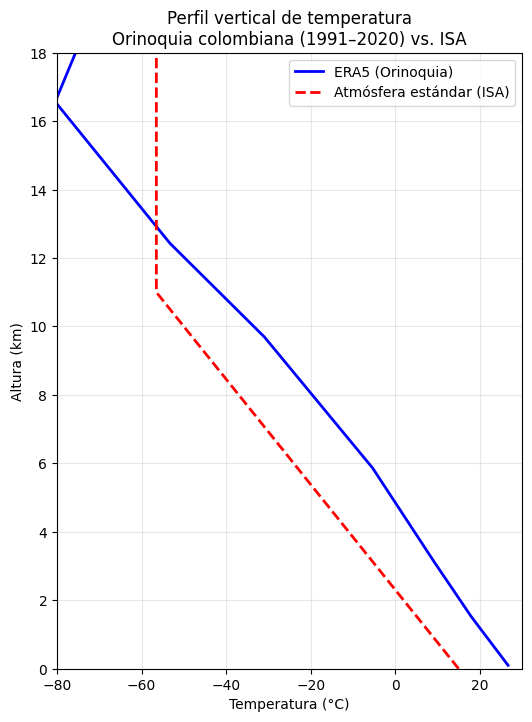

Figura guardada en: p:\clima\results\plots\05_perfil_vertical_temperatura.png


In [18]:
# ============================================================
# PERFIL VERTICAL DE TEMPERATURA (corregido)
# ============================================================
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Rutas (usando las definiciones que ya tienes)
PROJECT_ROOT = Path("p:/clima")
IN_PRESSURE = PROJECT_ROOT / "data" / "raw" / "era5_pressure_monthly_1991_2020.nc"

# Cargar datos
ds = xr.open_dataset(IN_PRESSURE)
tdim = "time" if "time" in ds.dims else "valid_time"
clim = ds.mean(dim=tdim, keep_attrs=True)

# Extraer temperatura (K) y geopotencial (m²/s²)
t_k = clim['t']
z = clim['z']
g = 9.80665
height = z / g                      # altura en metros

# Promedio espacial ponderado por área (cos(lat))
lat_weights = np.cos(np.deg2rad(clim.latitude))
weights = lat_weights / lat_weights.mean()
t_profile = (t_k * weights).mean(dim=('longitude','latitude')) - 273.15   # °C
h_profile = (height * weights).mean(dim=('longitude','latitude')) / 1000   # km

# Ordenar por altura creciente (los niveles de presión vienen de mayor a menor presión)
# La dimensión se llama 'pressure_level' (singular)
idx = np.argsort(h_profile.values)
h_profile_sorted = h_profile.isel(pressure_level=idx)
t_profile_sorted = t_profile.isel(pressure_level=idx)

# --- Atmósfera estándar (ISA) ---
def isa_temp(z_km):
    """Temperatura (°C) a la altura z_km (km) según ISA hasta 20 km."""
    z_m = z_km * 1000
    if z_m <= 11000:
        return 15 - 6.5 * z_km
    elif z_m <= 20000:
        return -56.5
    else:
        return -56.5   # simplificación

z_isa = np.linspace(0, h_profile_sorted.max().item(), 200)
t_isa = [isa_temp(z) for z in z_isa]

# --- Gráfico ---
fig, ax = plt.subplots(figsize=(6, 8))
ax.plot(t_profile_sorted, h_profile_sorted, 'b-', linewidth=2, label='ERA5 (Orinoquia)')
ax.plot(t_isa, z_isa, 'r--', linewidth=2, label='Atmósfera estándar (ISA)')
ax.set_xlabel('Temperatura (°C)')
ax.set_ylabel('Altura (km)')
ax.set_title('Perfil vertical de temperatura\nOrinoquia colombiana (1991–2020) vs. ISA')
ax.grid(True, alpha=0.3)
ax.legend()
ax.set_xlim(-80, 30)
ax.set_ylim(0, 18)

# Guardar la figura
out_png = PROJECT_ROOT / "results" / "plots" / "05_perfil_vertical_temperatura.png"
out_png.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(out_png, dpi=300)
plt.show()

print(f"Figura guardada en: {out_png}")